## Libraries and Imports

In [59]:
!pip install kaggle
!pip install kagglehub pandas scikit-learn joblib matplotlib
import kagglehub
import pandas as pd
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from joblib import dump
import csv


[notice] A new release of pip is available: 25.3 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Configuration

In [60]:
START_YEAR = 2010
END_YEAR = 2025
DATASET_SLUG = "keonim/nfl-game-scores-dataset-2017-2023"
SCORE_FILE = f"{START_YEAR}-{END_YEAR}_scores.csv"

REGULAR_SEASON_EXCLUDE = [
    "PRESEASON",
    "HALL OF FAME",
    "PRO BOWL",
    "WILD CARD",
    "DIVISIONAL",
    "CHAMPIONSHIP",
    "SUPER BOWL",
]

# Kept for compatibility with earlier cells/notes.
INVALID_WEEKS = REGULAR_SEASON_EXCLUDE

TEAM_COLUMNS = ["HomeTeam", "AwayTeam", "TeamWithPossession"]
SCORE_COLUMNS = ["AwayScore", "HomeScore"]
RANDOM_STATE = 42


## Team Normalization

In [61]:
TEAM_NAME_TO_ABBR = {
    "Arizona Cardinals": "ARI",
    "Atlanta Falcons": "ATL",
    "Baltimore Ravens": "BAL",
    "Buffalo Bills": "BUF",
    "Carolina Panthers": "CAR",
    "Chicago Bears": "CHI",
    "Cincinnati Bengals": "CIN",
    "Cleveland Browns": "CLE",
    "Dallas Cowboys": "DAL",
    "Denver Broncos": "DEN",
    "Detroit Lions": "DET",
    "Green Bay Packers": "GB",
    "Houston Texans": "HOU",
    "Indianapolis Colts": "IND",
    "Jacksonville Jaguars": "JAX",
    "Kansas City Chiefs": "KC",
    "Miami Dolphins": "MIA",
    "Minnesota Vikings": "MIN",
    "New England Patriots": "NE",
    "New Orleans Saints": "NO",
    "New York Giants": "NYG",
    "New York Jets": "NYJ",
    "Oakland Raiders": "LV",
    "Las Vegas Raiders": "LV",
    "Philadelphia Eagles": "PHI",
    "Pittsburgh Steelers": "PIT",
    "San Diego Chargers": "LAC",
    "Los Angeles Chargers": "LAC",
    "San Francisco 49ers": "SF",
    "Seattle Seahawks": "SEA",
    "St. Louis Rams": "LAR",
    "Los Angeles Rams": "LAR",
    "Tampa Bay Buccaneers": "TB",
    "Tennessee Titans": "TEN",
    "Washington Redskins": "WAS",
    "Washington Football Team": "WAS",
    "Washington Commanders": "WAS",
}

TEAM_ABBR_ALIASES = {
    "ARI": "ARI", "ATL": "ATL", "BAL": "BAL", "BUF": "BUF",
    "CAR": "CAR", "CHI": "CHI", "CIN": "CIN", "CLE": "CLE",
    "DAL": "DAL", "DEN": "DEN", "DET": "DET", "GB": "GB",
    "HOU": "HOU", "IND": "IND", "JAC": "JAX", "JAX": "JAX",
    "KC": "KC", "MIA": "MIA", "MIN": "MIN", "NE": "NE",
    "NO": "NO", "NYG": "NYG", "NYJ": "NYJ",
    "OAK": "LV", "LV": "LV",
    "PHI": "PHI", "PIT": "PIT",
    "SD": "LAC", "LAC": "LAC",
    "SF": "SF", "SEA": "SEA",
    "STL": "LAR", "LAR": "LAR",
    "TB": "TB", "TEN": "TEN", "WAS": "WAS",
}

TEAM_MAP = {**TEAM_NAME_TO_ABBR, **TEAM_ABBR_ALIASES}
TEAM_LOOKUP = {str(key).upper(): value for key, value in TEAM_MAP.items()}
VALID_TEAM_CODES = set(TEAM_ABBR_ALIASES.values())


## Load Dataset

In [62]:
path = kagglehub.dataset_download(DATASET_SLUG)

scores_path = os.path.join(path, SCORE_FILE)
plays_path_template = lambda year: os.path.join(path, f"{year}_plays.csv")

if not os.path.exists(scores_path):
    raise FileNotFoundError(f"Expected score file not found: {scores_path}")

scores_df = pd.read_csv(scores_path)

print(f"Dataset path: {path}")
print(f"Scores loaded: {scores_df.shape}")


Dataset path: C:\Users\mshan\.cache\kagglehub\datasets\keonim\nfl-game-scores-dataset-2017-2023\versions\45
Scores loaded: (5832, 9)


## Data Cleaning pt. 1

In [63]:
def strip_whitespace(df):
    df = df.copy()
    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = df[col].str.strip()
    return df


def normalize_team_value(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    return TEAM_LOOKUP.get(text.upper(), text.upper())


def normalize_teams(df, columns=TEAM_COLUMNS):
    df = df.copy()
    for col in columns:
        if col in df.columns:
            df[col] = df[col].map(normalize_team_value)
    return df


def filter_regular_season(df):
    df = df.copy()
    pattern = "|".join(REGULAR_SEASON_EXCLUDE)
    week = df["Week"].astype(str).str.upper().str.strip()
    keep = week.str.match(r"^WEEK\s+\d+$", na=False)
    keep &= ~week.str.contains(pattern, na=False)

    if "GameStatus" in df.columns:
        status = df["GameStatus"].astype(str).str.upper().str.strip()
        keep &= status.ne("BYE")

    return df.loc[keep].copy()


def extract_week_number(week):
    match = re.search(r"\d+", str(week))
    return int(match.group(0)) if match else np.nan


def create_game_id(df):
    df = df.copy()
    required = ["Season", "Week", "HomeTeam", "AwayTeam"]
    df = df.dropna(subset=required)

    df["Season"] = df["Season"].astype(int)
    df["Week"] = df["Week"].astype(str).str.upper().str.strip()
    df["WeekNumber"] = df["Week"].map(extract_week_number)

    teams = pd.DataFrame(
        np.sort(df[["HomeTeam", "AwayTeam"]].astype(str).values, axis=1),
        index=df.index,
        columns=["T1", "T2"],
    )

    df["GameId"] = (
        df["Season"].astype(str)
        + "_" + df["Week"]
        + "_" + teams["T1"]
        + "_" + teams["T2"]
    )
    return df


def load_plays_file_custom(file_path):
    rows = []
    with open(file_path, "r", encoding="utf-8", newline="") as f:
        reader = csv.reader(f)
        header = next(reader)
        for row in reader:
            if len(row) < 16:
                continue
            fixed = row[:15]
            play_description = ",".join(row[15:])
            rows.append(fixed + [play_description])

    columns = [
        "Season", "Week", "GameSlot", "Date",
        "AwayTeam", "HomeTeam",
        "Quarter", "DriveNumber",
        "TeamWithPossession",
        "IsScoringDrive",
        "PlayNumberInDrive",
        "IsScoringPlay",
        "PlayOutcome",
        "PlayStart",
        "PlayTimeFormation",
        "PlayDescription",
    ]
    return pd.DataFrame(rows, columns=columns)


def unknown_team_values(df, columns):
    unknown = {}
    for col in columns:
        if col in df.columns:
            values = sorted(set(df[col].dropna()) - VALID_TEAM_CODES)
            if values:
                unknown[col] = values
    return unknown


def parse_kickoff_team(row):
    text = f"{row.get('PlayOutcome', '')} {row.get('PlayDescription', '')}".upper()
    patterns = [
        r"KICKOFF FROM\s+([A-Z]{2,3})\s+\d+",
        r"KICKS\s+\d+\s+YARDS\s+FROM\s+([A-Z]{2,3})\s+\d+",
    ]
    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            return normalize_team_value(match.group(1))
    return np.nan


def parse_kickoff_recovery_team(row):
    text = str(row.get("PlayDescription", "")).upper()
    match = re.search(r"RECOVERED BY\s+([A-Z]{2,3})-", text)
    if match:
        return normalize_team_value(match.group(1))
    return np.nan


def receiving_team_for_kickoff(row, kicking_team):
    if pd.isna(kicking_team):
        return np.nan
    teams = {row["HomeTeam"], row["AwayTeam"]}
    other_teams = sorted(teams - {kicking_team})
    return other_teams[0] if len(other_teams) == 1 else np.nan


def correct_kickoff_drive_possession(df):
    df = df.copy()
    df["TeamWithPossession_Source"] = df["TeamWithPossession"]
    correction_count = 0

    group_cols = ["GameId", "Quarter", "DriveNumber"]
    for _, group in df.groupby(group_cols, sort=False, dropna=False):
        group = group.sort_index()
        if group.empty:
            continue

        first_idx = group.index[0]
        first_row = group.loc[first_idx]
        first_outcome = str(first_row.get("PlayOutcome", "")).upper()
        if "KICKOFF" not in first_outcome:
            continue

        kicking_team = parse_kickoff_team(first_row)
        receiving_team = receiving_team_for_kickoff(first_row, kicking_team)
        recovery_team = parse_kickoff_recovery_team(first_row)
        next_possession = recovery_team if pd.notna(recovery_team) else receiving_team
        if pd.isna(next_possession):
            continue

        rows_after_kickoff = group.index[1:]
        changed = df.loc[rows_after_kickoff, "TeamWithPossession"].ne(next_possession)
        correction_count += int(changed.sum())
        df.loc[rows_after_kickoff, "TeamWithPossession"] = next_possession

    return df, correction_count


## Load Play Data Raw

In [64]:
plays_list = []
missing_play_files = []

for year in range(START_YEAR, END_YEAR + 1):
    file_path = plays_path_template(year)

    if not os.path.exists(file_path):
        missing_play_files.append(file_path)
        continue

    try:
        df_temp = pd.read_csv(file_path)
    except pd.errors.ParserError:
        df_temp = load_plays_file_custom(file_path)

    plays_list.append(df_temp)

if not plays_list:
    raise FileNotFoundError("No play files were loaded.")

plays_df = pd.concat(plays_list, ignore_index=True)

print(f"Plays loaded: {plays_df.shape}")
if missing_play_files:
    print(f"Missing play files: {len(missing_play_files)}")


Plays loaded: (891829, 16)


## Data Cleaning pt 2 and Validation

In [65]:
scores_df = scores_df.copy()
plays_df = plays_df.copy()

scores_df["Season"] = pd.to_numeric(scores_df["Season"], errors="coerce")
plays_df["Season"] = pd.to_numeric(plays_df["Season"], errors="coerce")

scores_df = scores_df.dropna(subset=["Season"])
plays_df = plays_df.dropna(subset=["Season"])

scores_df = normalize_teams(strip_whitespace(scores_df))
plays_df = normalize_teams(strip_whitespace(plays_df))

scores_df = filter_regular_season(scores_df)
plays_df = filter_regular_season(plays_df)

for col in SCORE_COLUMNS:
    scores_df[col] = pd.to_numeric(scores_df[col], errors="coerce")

no_score_games = scores_df[scores_df[SCORE_COLUMNS].isna().any(axis=1)].copy()
scores_df = scores_df.dropna(subset=SCORE_COLUMNS).copy()

unknown_scores = unknown_team_values(scores_df, ["HomeTeam", "AwayTeam"])
unknown_plays = unknown_team_values(plays_df, TEAM_COLUMNS)
if unknown_scores or unknown_plays:
    raise ValueError({"unknown_score_teams": unknown_scores, "unknown_play_teams": unknown_plays})

scores_df = create_game_id(scores_df)
plays_df = create_game_id(plays_df)
plays_df, kickoff_possession_corrections = correct_kickoff_drive_possession(plays_df)

score_game_ids = set(scores_df["GameId"].unique())
play_game_ids = set(plays_df["GameId"].unique())
missing_play_game_ids = sorted(score_game_ids - play_game_ids)
extra_play_game_ids = sorted(play_game_ids - score_game_ids)

if missing_play_game_ids:
    print("Score games missing play data:", missing_play_game_ids[:10])
if extra_play_game_ids:
    print("Play games missing score data:", extra_play_game_ids[:10])

valid_game_ids = score_game_ids & play_game_ids
scores_df = scores_df[scores_df["GameId"].isin(valid_game_ids)].copy()
plays_df = plays_df[plays_df["GameId"].isin(valid_game_ids)].copy()

scores_df["HomeMargin"] = scores_df["HomeScore"] - scores_df["AwayScore"]
scores_df["HomeResult"] = np.select(
    [scores_df["HomeMargin"] > 0, scores_df["HomeMargin"] < 0],
    [1.0, 0.0],
    default=0.5,
)
scores_df["HomeWin"] = np.select(
    [scores_df["HomeMargin"] > 0, scores_df["HomeMargin"] < 0],
    [1, 0],
    default=np.nan,
)

model_scores_df = scores_df.dropna(subset=["HomeWin"]).copy()
model_scores_df["HomeWin"] = model_scores_df["HomeWin"].astype(int)

print("Cleaning complete")
print(f"Dropped no-score games: {len(no_score_games)}")
print(f"Kickoff-drive possession corrections: {kickoff_possession_corrections}")
print(f"Score games with play data: {scores_df['GameId'].nunique()}")
print(f"Play games with score data: {plays_df['GameId'].nunique()}")
print(f"Ties excluded from binary model target: {scores_df['HomeWin'].isna().sum()}")
print(scores_df.shape, plays_df.shape)


Cleaning complete
Dropped no-score games: 1
Kickoff-drive possession corrections: 3501
Score games with play data: 4175
Play games with score data: 4175
Ties excluded from binary model target: 13
(4175, 14) (711117, 19)


## GameID 

In [66]:
# GameId is created during cleaning/validation so scores and plays use the same key.
print(scores_df[["Season", "Week", "AwayTeam", "HomeTeam", "GameId"]].head())
print(plays_df[["Season", "Week", "AwayTeam", "HomeTeam", "TeamWithPossession", "GameId"]].head())


    Season    Week AwayTeam HomeTeam               GameId
65    2010  WEEK 1      MIN       NO   2010_WEEK 1_MIN_NO
66    2010  WEEK 1      CLE       TB   2010_WEEK 1_CLE_TB
67    2010  WEEK 1      MIA      BUF  2010_WEEK 1_BUF_MIA
68    2010  WEEK 1      CIN       NE   2010_WEEK 1_CIN_NE
69    2010  WEEK 1      IND      HOU  2010_WEEK 1_HOU_IND
       Season    Week AwayTeam HomeTeam TeamWithPossession              GameId
10947    2010  WEEK 1      MIN       NO                 NO  2010_WEEK 1_MIN_NO
10948    2010  WEEK 1      MIN       NO                 NO  2010_WEEK 1_MIN_NO
10949    2010  WEEK 1      MIN       NO                 NO  2010_WEEK 1_MIN_NO
10950    2010  WEEK 1      MIN       NO                 NO  2010_WEEK 1_MIN_NO
10951    2010  WEEK 1      MIN       NO                 NO  2010_WEEK 1_MIN_NO


## Play Features

In [67]:
RUSH_TERMS = [
    " rush", "run", "scramble", "scrambles", "kneel",
    "up the middle", "left end", "right end",
    "left tackle", "right tackle", "left guard", "right guard",
]


def contains_any(text, terms):
    return any(term in text for term in terms)


def classify_play(outcome, desc):
    outcome_text = str(outcome).lower()
    desc_text = str(desc).lower()
    text = f"{outcome_text} {desc_text}"

    if "timeout" in text:
        return "Timeout"
    if "touchdown" in text:
        return "Touchdown"
    if "safety" in outcome_text:
        return "Safety"
    if "penalty" in outcome_text:
        return "Penalty"
    if "field goal" in text:
        return "FieldGoal"
    if "extra point" in text:
        return "ExtraPoint"
    if "punt" in text:
        return "Punt"
    if "kickoff" in text:
        return "Kickoff"
    if "sack" in outcome_text or "sacked" in desc_text:
        return "Sack"
    if (
        "pass" in text
        or "interception" in outcome_text
        or "intercepted" in desc_text
        or "spike" in text
    ):
        return "Pass"
    if contains_any(text, RUSH_TERMS):
        return "Rush"
    if "fumble" in text:
        return "Fumble"
    if "no play" in text:
        return "NoPlay"
    return "Other"


def extract_yards(outcome, desc):
    outcome_text = str(outcome).lower().strip()
    desc_text = str(desc).lower()
    text = f"{outcome_text} {desc_text}"

    if "no play" in text:
        return 0
    if "penalty" in outcome_text:
        return 0
    if "incomplete" in outcome_text:
        return 0
    if "interception" in outcome_text or "intercepted" in desc_text:
        return 0
    if "touchback" in outcome_text:
        return 0

    outcome_match = re.match(r"^\s*(-?\d+)\s*yard", outcome_text)
    if outcome_match:
        return int(outcome_match.group(1))

    if "no gain" in desc_text:
        return 0

    for pattern in [r"for (-?\d+)\s*yards?", r"gain of (-?\d+)"]:
        match = re.search(pattern, desc_text)
        if match:
            return int(match.group(1))

    return 0


plays_df["PlayType_Fixed"] = plays_df.apply(
    lambda x: classify_play(x["PlayOutcome"], x["PlayDescription"]),
    axis=1,
)

plays_df["Yards_Fixed"] = plays_df.apply(
    lambda x: extract_yards(x["PlayOutcome"], x["PlayDescription"]),
    axis=1,
)

plays_df["IsInterception"] = (
    plays_df["PlayOutcome"].astype(str).str.contains("Interception|Intercepted", case=False, na=False)
    | plays_df["PlayDescription"].astype(str).str.contains("INTERCEPTED", case=False, na=False)
).astype(int)
plays_df["IsFumble"] = plays_df["PlayDescription"].astype(str).str.contains("FUMBLES", case=False, na=False).astype(int)

print(plays_df["PlayType_Fixed"].value_counts())


PlayType_Fixed
Pass          273045
Rush          214723
Kickoff        42336
Penalty        36302
Punt           35969
Timeout        30993
Touchdown      22744
Sack           19534
ExtraPoint     18457
FieldGoal      16220
Fumble           556
Safety           238
Name: count, dtype: int64


## Team Aggregation

In [68]:
OFFENSIVE_PLAY_TYPES = ["Pass", "Rush", "Sack"]

offensive_plays = plays_df[
    plays_df["PlayType_Fixed"].isin(OFFENSIVE_PLAY_TYPES)
].copy()

offensive_plays["PassAttempts"] = (offensive_plays["PlayType_Fixed"] == "Pass").astype(int)
offensive_plays["RushAttempts"] = (offensive_plays["PlayType_Fixed"] == "Rush").astype(int)
offensive_plays["SacksTaken"] = (offensive_plays["PlayType_Fixed"] == "Sack").astype(int)
offensive_plays["PassingYards"] = np.where(
    offensive_plays["PlayType_Fixed"] == "Pass",
    offensive_plays["Yards_Fixed"],
    0,
)
offensive_plays["SackYards"] = np.where(
    offensive_plays["PlayType_Fixed"] == "Sack",
    offensive_plays["Yards_Fixed"],
    0,
)
offensive_plays["RushingYards"] = np.where(
    offensive_plays["PlayType_Fixed"] == "Rush",
    offensive_plays["Yards_Fixed"],
    0,
)
offensive_plays["Turnovers"] = (
    (offensive_plays["IsInterception"] == 1) | (offensive_plays["IsFumble"] == 1)
).astype(int)

game_offense = offensive_plays.groupby(
    ["GameId", "TeamWithPossession"],
    as_index=False,
).agg(
    PassingYards=("PassingYards", "sum"),
    SackYards=("SackYards", "sum"),
    RushingYards=("RushingYards", "sum"),
    PassAttempts=("PassAttempts", "sum"),
    RushAttempts=("RushAttempts", "sum"),
    SacksTaken=("SacksTaken", "sum"),
    Turnovers=("Turnovers", "sum"),
)

game_offense = game_offense.rename(columns={"TeamWithPossession": "Team"})
game_offense["NetPassingYards"] = game_offense["PassingYards"] + game_offense["SackYards"]
game_offense["TotalOffensivePlays"] = (
    game_offense["PassAttempts"]
    + game_offense["RushAttempts"]
    + game_offense["SacksTaken"]
)
game_offense["OffensiveYards"] = game_offense["NetPassingYards"] + game_offense["RushingYards"]
game_offense["YardsPerPlay"] = np.where(
    game_offense["TotalOffensivePlays"] > 0,
    game_offense["OffensiveYards"] / game_offense["TotalOffensivePlays"],
    np.nan,
)

expected_team_games = pd.concat(
    [
        scores_df[["GameId", "HomeTeam"]].rename(columns={"HomeTeam": "Team"}),
        scores_df[["GameId", "AwayTeam"]].rename(columns={"AwayTeam": "Team"}),
    ],
    ignore_index=True,
).drop_duplicates()

missing_team_games = expected_team_games.merge(
    game_offense[["GameId", "Team"]],
    on=["GameId", "Team"],
    how="left",
    indicator=True,
).query('_merge == "left_only"')

print(f"Team-game offense rows: {len(game_offense)}")
print(f"Expected team-game rows: {len(expected_team_games)}")
print(f"Missing team-game offense rows: {len(missing_team_games)}")


Team-game offense rows: 8350
Expected team-game rows: 8350
Missing team-game offense rows: 0


## Model-Ready Pregame Features

In [69]:
TEAM_GAME_BASE_COLUMNS = [
    "GameId", "Season", "Week", "WeekNumber", "GameDate",
    "Team", "Opponent", "IsHome",
    "PointsFor", "PointsAgainst", "Win",
]

home_team_games = scores_df.assign(
    Team=scores_df["HomeTeam"],
    Opponent=scores_df["AwayTeam"],
    IsHome=1,
    PointsFor=scores_df["HomeScore"],
    PointsAgainst=scores_df["AwayScore"],
    Win=scores_df["HomeResult"],
)[TEAM_GAME_BASE_COLUMNS]

away_team_games = scores_df.assign(
    Team=scores_df["AwayTeam"],
    Opponent=scores_df["HomeTeam"],
    IsHome=0,
    PointsFor=scores_df["AwayScore"],
    PointsAgainst=scores_df["HomeScore"],
    Win=1 - scores_df["HomeResult"],
)[TEAM_GAME_BASE_COLUMNS]

team_game_df = pd.concat([home_team_games, away_team_games], ignore_index=True)
team_game_df = team_game_df.merge(game_offense, on=["GameId", "Team"], how="left")

missing_offense = team_game_df["OffensiveYards"].isna().sum()
if missing_offense:
    print(f"Rows missing offense features: {missing_offense}")

OFFENSE_FEATURES = [
    "PassingYards", "SackYards", "RushingYards", "NetPassingYards",
    "PassAttempts", "RushAttempts", "SacksTaken", "Turnovers",
    "TotalOffensivePlays", "OffensiveYards", "YardsPerPlay",
]
for col in OFFENSE_FEATURES:
    team_game_df[col] = team_game_df[col].fillna(0)

team_game_df["PointDifferential"] = team_game_df["PointsFor"] - team_game_df["PointsAgainst"]
team_game_df = team_game_df.sort_values(["Team", "Season", "WeekNumber", "GameId"])

ROLLING_FEATURES = [
    "Win", "PointsFor", "PointsAgainst", "PointDifferential",
    "OffensiveYards", "YardsPerPlay", "NetPassingYards",
    "RushingYards", "Turnovers",
]

for col in ROLLING_FEATURES:
    team_game_df[f"PreGame_{col}"] = team_game_df.groupby("Team")[col].transform(
        lambda s: s.shift(1).rolling(window=8, min_periods=1).mean()
    )

pregame_cols = [f"PreGame_{col}" for col in ROLLING_FEATURES]
home_pre = team_game_df[team_game_df["IsHome"] == 1][["GameId"] + pregame_cols].rename(
    columns={col: f"Home_{col}" for col in pregame_cols}
)
away_pre = team_game_df[team_game_df["IsHome"] == 0][["GameId"] + pregame_cols].rename(
    columns={col: f"Away_{col}" for col in pregame_cols}
)

model_df = scores_df[[
    "GameId", "Season", "Week", "WeekNumber",
    "HomeTeam", "AwayTeam", "HomeScore", "AwayScore",
    "HomeMargin", "HomeWin",
]].merge(home_pre, on="GameId", how="left").merge(away_pre, on="GameId", how="left")

diff_cols = []
for col in ROLLING_FEATURES:
    diff_col = f"Diff_{col}"
    model_df[diff_col] = model_df[f"Home_PreGame_{col}"] - model_df[f"Away_PreGame_{col}"]
    diff_cols.append(diff_col)

model_df = model_df.dropna(subset=diff_cols + ["HomeWin"]).copy()
model_df["HomeWin"] = model_df["HomeWin"].astype(int)

print(f"Team-game feature rows: {team_game_df.shape}")
print(f"Model-ready rows: {model_df.shape}")
print("Use diff_cols as logistic regression inputs and HomeWin as the target.")


Team-game feature rows: (8350, 32)
Model-ready rows: (4146, 37)
Use diff_cols as logistic regression inputs and HomeWin as the target.


## Manual Stat Checks

In [70]:
# These checks are meant for a quick manual comparison against NFL/ team stat pages.
# Fill OfficialValue after looking up a number, then rerun this cell to see the diff.
season_team_stats = team_game_df.groupby(
    ["Season", "Team"],
    as_index=False,
).agg(
    Games=("GameId", "nunique"),
    PointsFor=("PointsFor", "sum"),
    PointsAgainst=("PointsAgainst", "sum"),
    PassingYards=("PassingYards", "sum"),
    SackYards=("SackYards", "sum"),
    NetPassingYards=("NetPassingYards", "sum"),
    RushingYards=("RushingYards", "sum"),
    OffensiveYards=("OffensiveYards", "sum"),
    PassAttempts=("PassAttempts", "sum"),
    RushAttempts=("RushAttempts", "sum"),
    SacksTaken=("SacksTaken", "sum"),
    Turnovers=("Turnovers", "sum"),
    TotalOffensivePlays=("TotalOffensivePlays", "sum"),
)
season_team_stats["YardsPerPlay"] = np.where(
    season_team_stats["TotalOffensivePlays"] > 0,
    season_team_stats["OffensiveYards"] / season_team_stats["TotalOffensivePlays"],
    np.nan,
)

integer_stat_cols = [
    "Games", "PointsFor", "PointsAgainst", "PassingYards", "SackYards",
    "NetPassingYards", "RushingYards", "OffensiveYards", "PassAttempts",
    "RushAttempts", "SacksTaken", "Turnovers", "TotalOffensivePlays",
]
season_team_stats[integer_stat_cols] = season_team_stats[integer_stat_cols].round(0).astype(int)
season_team_stats = season_team_stats.sort_values(["Season", "Team"]).reset_index(drop=True)

manual_checks = pd.DataFrame([
    {"Season": 2023, "Team": "DAL", "Stat": "PassingYards", "OfficialValue": np.nan},
    {"Season": 2023, "Team": "DAL", "Stat": "RushingYards", "OfficialValue": np.nan},
    {"Season": 2023, "Team": "DAL", "Stat": "OffensiveYards", "OfficialValue": np.nan},
    {"Season": 2010, "Team": "ARI", "Stat": "OffensiveYards", "OfficialValue": np.nan},
    {"Season": 2010, "Team": "ARI", "Stat": "PassingYards", "OfficialValue": np.nan},
    {"Season": 2010, "Team": "ARI", "Stat": "RushingYards", "OfficialValue": np.nan},
    {"Season": 2023, "Team": "KC", "Stat": "SacksTaken", "OfficialValue": np.nan},
    {"Season": 2023, "Team": "SF", "Stat": "YardsPerPlay", "OfficialValue": np.nan},
])


def lookup_pipeline_stat(row):
    match = season_team_stats[
        (season_team_stats["Season"] == row["Season"])
        & (season_team_stats["Team"] == row["Team"])
    ]
    if match.empty:
        return np.nan
    return match.iloc[0][row["Stat"]]


manual_checks["PipelineValue"] = manual_checks.apply(lookup_pipeline_stat, axis=1)
manual_checks["Difference"] = manual_checks["PipelineValue"] - manual_checks["OfficialValue"]
manual_checks["CheckStatus"] = np.where(
    manual_checks["OfficialValue"].isna(),
    "fill OfficialValue",
    np.where(manual_checks["Difference"].abs() <= 0.1, "match", "review"),
)

print("Other play-type audit after explicit Timeout/Safety classification:")
print(plays_df["PlayType_Fixed"].value_counts())

print("\nManual check targets:")
display(manual_checks[[
    "Season", "Team", "Stat", "PipelineValue", "OfficialValue", "Difference", "CheckStatus",
]])

print("\nFull rows for the example teams:")
display(
    season_team_stats[
        season_team_stats[["Season", "Team"]].apply(tuple, axis=1).isin([
            (2023, "DAL"),
            (2010, "ARI"),
            (2023, "KC"),
            (2023, "SF"),
        ])
    ]
)


Other play-type audit after explicit Timeout/Safety classification:
PlayType_Fixed
Pass          273045
Rush          214723
Kickoff        42336
Penalty        36302
Punt           35969
Timeout        30993
Touchdown      22744
Sack           19534
ExtraPoint     18457
FieldGoal      16220
Fumble           556
Safety           238
Name: count, dtype: int64

Manual check targets:


,Season,Team,Stat,PipelineValue,OfficialValue,Difference,CheckStatus
0,2023,DAL,PassingYards,4162.000000,NaN,NaN,fill OfficialValue
1,2023,DAL,RushingYards,1821.000000,NaN,NaN,fill OfficialValue
2,2023,DAL,OffensiveYards,5723.000000,NaN,NaN,fill OfficialValue
3,2010,ARI,OffensiveYards,3929.000000,NaN,NaN,fill OfficialValue
4,2010,ARI,PassingYards,3054.000000,NaN,NaN,fill OfficialValue
5,2010,ARI,RushingYards,1171.000000,NaN,NaN,fill OfficialValue
6,2023,KC,SacksTaken,29.000000,NaN,NaN,fill OfficialValue
7,2023,SF,YardsPerPlay,6.065421,NaN,NaN,fill OfficialValue



Full rows for the example teams:


,Season,Team,Games,PointsFor,PointsAgainst,PassingYards,SackYards,NetPassingYards,RushingYards,OffensiveYards,PassAttempts,RushAttempts,SacksTaken,Turnovers,TotalOffensivePlays,YardsPerPlay
0,2010,ARI,16,289,434,3054,-296,2758,1171,3929,542,307,48,39,897,4.380156
424,2023,DAL,17,509,315,4162,-260,3902,1821,5723,576,455,39,20,1070,5.348598
431,2023,KC,17,371,294,4106,-185,3921,1736,5657,605,411,29,31,1045,5.413397
444,2023,SF,17,491,298,3890,-194,3696,2145,5841,457,473,33,25,963,6.065421


## Logistic Regression Model

In [71]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss

In [72]:

train_df = model_df[
    model_df["Season"] <= 2022
].copy()

test_df = model_df[
    model_df["Season"] > 2022
].copy()


X_train = train_df[diff_cols]
y_train = train_df["HomeWin"]

X_test = test_df[diff_cols]
y_test = test_df["HomeWin"]


print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)


Training samples: (3331, 9)
Testing samples: (815, 9)


## model evaluation

In [73]:
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        log_predictions
    )
)

print(
    confusion_matrix(
        y_test,
        log_predictions
    )
)

Accuracy: 0.6331288343558282
[[194 179]
 [120 322]]


## Scaling

In [74]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



## Gradient Descent

In [75]:

log_model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000
)

log_model.fit(
    X_train_scaled,
    y_train
)

log_predictions = log_model.predict(
    X_test_scaled
)

log_probabilities = log_model.predict_proba(
    X_test_scaled
)[:,1]

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        log_predictions
    )
)

print(
    "Log Loss:",
    log_loss(
        y_test,
        log_probabilities
    )
)

print(
    "Confusion Matrix:"
)

print(
    confusion_matrix(
        y_test,
        log_predictions
    )
)

Accuracy: 0.6331288343558282
Log Loss: 0.6408637829874709
Confusion Matrix:
[[194 179]
 [120 322]]


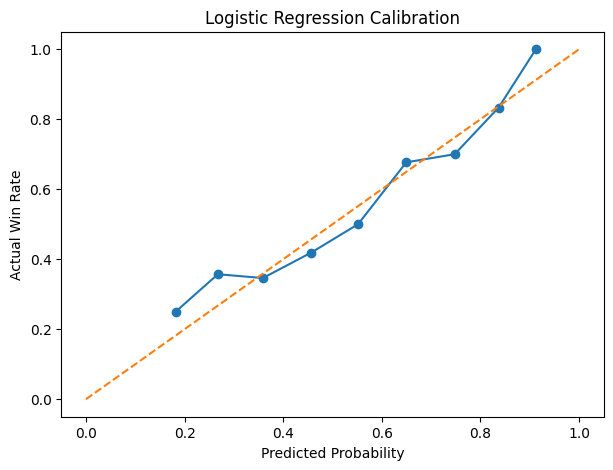

In [76]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    y_test,
    log_probabilities,
    n_bins=10
)

plt.figure(figsize=(7,5))

plt.plot(
    prob_pred,
    prob_true,
    marker="o"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("Predicted Probability")
plt.ylabel("Actual Win Rate")
plt.title("Logistic Regression Calibration")

plt.show()

## Monte Carlo Simulation

In [ ]:

import numpy as np
import pandas as pd

DIVISIONS = {
    "AFC_North":
        ["BAL","CIN","CLE","PIT"],
    "AFC_South":
        ["HOU","IND","JAX","TEN"],
    "AFC_East":
        ["BUF","MIA","NE","NYJ"],
    "AFC_West":
        ["KC","LV","DEN","LAC"],

    "NFC_North":
        ["DET","GB","CHI","MIN"],
    "NFC_South":
        ["TB","ATL","NO","CAR"],
    "NFC_East":
        ["PHI","DAL","NYG","WAS"],
    "NFC_West":
        ["SF","SEA","LAR","ARI"]
}

team_feature_snapshot = {}


for team in VALID_TEAM_CODES:
    latest = (
        team_game_df[
            team_game_df["Team"] == team
        ]
        .sort_values(
            ["Season","WeekNumber"]
        )
    )


    if len(latest) > 0:
        team_feature_snapshot[team] = (
            latest.iloc[-1][
                [
                    f"PreGame_{x}"
                    for x in ROLLING_FEATURES
                ]
            ]
            .values
        )



print(
    "Teams with feature snapshots:",
    len(team_feature_snapshot)
)


def get_win_probability(home, away):

    home_features = team_feature_snapshot[home]
    away_features = team_feature_snapshot[away]

    difference = (
        home_features -
        away_features
    )

    probability = log_model.predict_proba(
        difference.reshape(1,-1)
    )[0][1]

    return probability


# base season 

def initialize_standings():
    standings = {}

    for team in VALID_TEAM_CODES:
        standings[team] = {
            "wins":0,
            "losses":0
        }

    return standings


# simulate single game

def simulate_game(home, away, standings):

    probability = get_win_probability(
        home,
        away
    )

    if np.random.random() < probability:
        winner = home
        loser = away

    else:
        winner = away
        loser = home

    standings[winner]["wins"] += 1
    standings[loser]["losses"] += 1

    return winner


# simulate season

def simulate_regular_season(schedule):

    standings = initialize_standings()

    for _,game in schedule.iterrows():
        simulate_game(
            game["HomeTeam"],
            game["AwayTeam"],
            standings
        )

    return standings


# create playoffs

def get_division_winner(
    division,
    standings
):

    teams = DIVISIONS[division]

    ranked = sorted(
        teams,
        key=lambda x:
            standings[x]["wins"],
        reverse=True
    )

    return ranked[0]


def create_conference_playoff_field(
    conference,
    standings
):

    divisions = [
        d for d in DIVISIONS
        if conference in d
    ]

    division_winners = []

    for division in divisions:
        division_winners.append(
            get_division_winner(
                division,
                standings
            )
        )

    all_teams = [
        team
        for division in divisions
        for team in DIVISIONS[division]
    ]

    remaining = [
        team
        for team in all_teams
        if team not in division_winners
    ]



    wildcards = sorted(
        remaining,
        key=lambda x:
            standings[x]["wins"],
        reverse=True
    )[:3]



    playoff_field = division_winners + wildcards


    return sorted(
        playoff_field,
        key=lambda x:
            standings[x]["wins"],
        reverse=True
    )


# playoff simulation


def playoff_game(team1, team2):

    probability = get_win_probability(
        team1,
        team2
    )

    if np.random.random() < probability:
        return team1
    else:
        return team2



def simulate_round(teams):

    winners=[]

    for i in range(0,len(teams),2):
        winners.append(
            playoff_game(
                teams[i],
                teams[i+1]
            )
        )

    return winners





def simulate_playoffs(
    standings
):


    afc = create_conference_playoff_field(
        "AFC",
        standings
    )


    nfc = create_conference_playoff_field(
        "NFC",
        standings
    )

#will fix bracket eventually to be more accurate to nfl rules

    afc_winner = afc[0]

    for team in afc[1:]:
        afc_winner = playoff_game(
            afc_winner,
            team
        )


    nfc_winner = nfc[0]

    for team in nfc[1:]:
        nfc_winner = playoff_game(
            nfc_winner,
            team
        )


    superbowl_winner = playoff_game(
        afc_winner,
        nfc_winner
    )

    return superbowl_winner


# monte carlo sim

def monte_carlo_simulation(
    schedule,
    iterations=10000
):

    champions = {}

    for i in range(iterations):
        standings = simulate_regular_season(
            schedule
        )

        champion = simulate_playoffs(
            standings
        )

        champions[champion] = (
            champions.get(champion,0)
            +1
        )

    results = pd.DataFrame(
        {
            "Team":
                champions.keys(),
            "SuperBowl_Wins":
                champions.values()
        }
    )

    results["Probability"] = (
        results["SuperBowl_Wins"]
        /
        iterations
    )

    return results.sort_values(
        "Probability",
        ascending=False
    )


# schedule

simulation_schedule = scores_df[
    [
        "Season",
        "WeekNumber",
        "HomeTeam",
        "AwayTeam"
    ]

].copy()


# Only simulate latest season

simulation_schedule = simulation_schedule[
    simulation_schedule["Season"]
    ==
    simulation_schedule["Season"].max()
]

print(
    simulation_schedule.head()
)


# run sim

superbowl_results = monte_carlo_simulation(
    simulation_schedule,
    iterations=10000
)


print(
    superbowl_results
)

Teams with feature snapshots: 32
      Season  WeekNumber HomeTeam AwayTeam
5513    2025           1      PHI      DAL
5514    2025           1      LAC       KC
5515    2025           1      ATL       TB
5516    2025           1      CLE      CIN
5517    2025           1      IND      MIA
   Team  SuperBowl_Wins  Probability
2   LAR            5742       0.5742
0    SF            1978       0.1978
1   JAX             965       0.0965
3   SEA             829       0.0829
4    NE             419       0.0419
5   BAL              40       0.0040
6   CHI              14       0.0014
7   HOU               8       0.0008
8   BUF               2       0.0002
9   DAL               1       0.0001
10  DEN               1       0.0001
11  CIN               1       0.0001
